# Transaction-cost-aware neural hedging extension

This notebook extends the baseline neural hedging experiment by adding **proportional transaction costs**.  
The baseline Black--Scholes experiment is deliberately frictionless, so the selected neural hedge should closely match the analytic delta hedge. Once trading costs are introduced, however, the analytic Black--Scholes delta is no longer an obvious optimal strategy because it rebalances aggressively.

The aim of this extension is therefore to test whether the same selected architecture can learn a hedge that trades off replication accuracy against turnover.

## Core experiment

We compare:

1. **Black--Scholes delta at the frictionless premium**: naive benchmark that ignores trading costs.
2. **Black--Scholes delta with cost-adjusted premium**: same hedge, but the premium is shifted to account for expected trading costs.
3. **Black--Scholes no-trade band**: a simple turnover-reduction benchmark.
4. **Frictionless neural hedge evaluated after costs**: neural hedge trained with zero costs, then exposed to trading costs.
5. **Cost-aware neural hedge**: same selected architecture, trained directly with transaction costs in the wealth recursion.

The key metrics are RMSE, mean hedge error, turnover, mean transaction cost, and seller shortfall risk.


## Transaction cost model

The frictionless terminal wealth convention in the main report is

\[
V_T = \pi + \sum_{n=0}^{N-1}\delta_n(S_{t_{n+1}}-S_{t_n}).
\]

With proportional transaction costs, we use

\[
V_T^{\lambda}
=
\pi
+
\sum_{n=0}^{N-1}\delta_n(S_{t_{n+1}}-S_{t_n})
-
\lambda\sum_{n=0}^{N-1}S_{t_n}\lvert \delta_n-\delta_{n-1}\rvert,
\qquad \delta_{-1}=0.
\]

The notebook also includes an optional terminal liquidation cost

\[
\lambda S_T |\delta_{N-1}|,
\]

controlled by `INCLUDE_TERMINAL_LIQUIDATION`. For the report, state clearly which convention you use.

The neural hedge is trained by minimizing

\[
\mathcal{L}_{\lambda}(\theta)
=
\mathbb{E}\left[\left(V_T^{\lambda,\theta}-\Phi(S_T)\right)^2\right].
\]

The learned premium is therefore the MSE-optimal scalar intercept under the chosen transaction-cost convention. It should not be interpreted as a unique no-arbitrage price in a market with frictions.


In [19]:
# ============================================================
# Imports and global settings
# ============================================================

import math
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Output directory
OUTPUT_DIR = Path("transaction_cost_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


Using device: cuda


## Configuration

The default settings are a reasonably fast run. For report-quality results, set `RUN_FULL = True`.

Suggested final report setting:

- `TRAIN_PATHS = 100_000`
- `VAL_PATHS = 50_000`
- `TEST_PATHS = 100_000`
- `EPOCHS = 150`
- `COST_RATES = [0.0, 0.0005, 0.0010, 0.0025, 0.0050]`

Here, `0.0010` corresponds to 10 basis points or 0.10% proportional transaction cost per currency unit traded.


In [20]:
# ============================================================
# Model and experiment configuration
# ============================================================

RUN_FULL = True  # Set to True for report-quality runs

# Black--Scholes baseline parameters
S0 = 1.0
K = 0.9
SIGMA = 0.4
T = 0.5
R = 0.0
N = 125
DT = T / N

# Transaction cost convention
INCLUDE_TERMINAL_LIQUIDATION = True

if RUN_FULL:
    TRAIN_PATHS = 100_000
    VAL_PATHS = 50_000
    TEST_PATHS = 100_000
    EPOCHS = 150
    BATCH_SIZE = 4096
    COST_RATES = [0.0, 0.0005, 0.0010, 0.0025, 0.0050]
else:
    TRAIN_PATHS = 20_000
    VAL_PATHS = 10_000
    TEST_PATHS = 30_000
    EPOCHS = 60
    BATCH_SIZE = 4096
    COST_RATES = [0.0, 0.0005, 0.0010, 0.0025]

LR = 1e-3
WEIGHT_DECAY = 0.0
HIDDEN_WIDTH = 64
HIDDEN_DEPTH = 3
PRINT_EVERY = max(1, EPOCHS // 10)

# No-trade band candidates for the simple BS benchmark
NO_TRADE_BANDS = [0.0, 0.0025, 0.005, 0.01, 0.02, 0.05]

print({
    "RUN_FULL": RUN_FULL,
    "TRAIN_PATHS": TRAIN_PATHS,
    "VAL_PATHS": VAL_PATHS,
    "TEST_PATHS": TEST_PATHS,
    "EPOCHS": EPOCHS,
    "COST_RATES": COST_RATES,
    "INCLUDE_TERMINAL_LIQUIDATION": INCLUDE_TERMINAL_LIQUIDATION,
})


{'RUN_FULL': True, 'TRAIN_PATHS': 100000, 'VAL_PATHS': 50000, 'TEST_PATHS': 100000, 'EPOCHS': 150, 'COST_RATES': [0.0, 0.0005, 0.001, 0.0025, 0.005], 'INCLUDE_TERMINAL_LIQUIDATION': True}


In [21]:
# ============================================================
# Black--Scholes helpers and GBM simulation
# ============================================================

def norm_cdf(x: torch.Tensor) -> torch.Tensor:
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def bs_call_price_scalar(S0=S0, K=K, sigma=SIGMA, T=T, r=R) -> float:
    """Black--Scholes European call price at t=0 as a Python float."""
    if T <= 0:
        return max(S0 - K, 0.0)
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    N_d1 = 0.5 * (1.0 + math.erf(d1 / math.sqrt(2.0)))
    N_d2 = 0.5 * (1.0 + math.erf(d2 / math.sqrt(2.0)))
    return S0 * N_d1 - K * math.exp(-r * T) * N_d2


def simulate_gbm_paths(n_paths: int, seed: int, device=DEVICE) -> torch.Tensor:
    """Simulate GBM paths with shape (n_paths, N+1)."""
    gen = torch.Generator(device=device)
    gen.manual_seed(seed)
    Z = torch.randn((n_paths, N), generator=gen, device=device)
    increments = (R - 0.5 * SIGMA**2) * DT + SIGMA * math.sqrt(DT) * Z
    logS = math.log(S0) + torch.cumsum(increments, dim=1)
    S = torch.cat([
        torch.full((n_paths, 1), S0, device=device),
        torch.exp(logS)
    ], dim=1)
    return S


def payoff_call(S: torch.Tensor) -> torch.Tensor:
    return torch.clamp(S[:, -1] - K, min=0.0)


def bs_delta_paths(S: torch.Tensor) -> torch.Tensor:
    """Black--Scholes delta sampled at t_0,...,t_{N-1}. Returns shape (paths, N)."""
    S_hedge = S[:, :-1]
    t_grid = torch.arange(N, device=S.device, dtype=S.dtype) * DT
    tau = torch.clamp(T - t_grid, min=1e-12)
    tau = tau.view(1, -1)
    d1 = (torch.log(S_hedge / K) + (R + 0.5 * SIGMA**2) * tau) / (SIGMA * torch.sqrt(tau))
    return norm_cdf(d1)


BS_PRICE = bs_call_price_scalar()
print(f"Black--Scholes price: {BS_PRICE:.8f}")


Black--Scholes price: 0.16411068


In [22]:
# ============================================================
# Transaction-cost wealth, metrics, and premium calibration
# ============================================================

def transaction_costs_and_turnover(
    S: torch.Tensor,
    delta: torch.Tensor,
    cost_rate: float,
    include_terminal_liquidation: bool = INCLUDE_TERMINAL_LIQUIDATION,
):
    """
    Returns transaction cost and value turnover for a hedge ratio process.

    delta has shape (paths, N), corresponding to holdings over [t_n,t_{n+1}].
    The position is assumed to start from zero before t_0.
    If include_terminal_liquidation is True, the final stock position is closed at T.
    """
    zeros = torch.zeros((delta.shape[0], 1), device=delta.device, dtype=delta.dtype)
    delta_prev = torch.cat([zeros, delta[:, :-1]], dim=1)
    abs_trade = torch.abs(delta - delta_prev)
    value_turnover = (S[:, :-1] * abs_trade).sum(dim=1)

    if include_terminal_liquidation:
        value_turnover = value_turnover + S[:, -1] * torch.abs(delta[:, -1])

    costs = cost_rate * value_turnover
    return costs, value_turnover


def terminal_wealth_after_costs(
    S: torch.Tensor,
    delta: torch.Tensor,
    premium,
    cost_rate: float,
    include_terminal_liquidation: bool = INCLUDE_TERMINAL_LIQUIDATION,
):
    """Terminal wealth after proportional transaction costs."""
    dS = S[:, 1:] - S[:, :-1]
    trading_pnl = (delta * dS).sum(dim=1)
    costs, value_turnover = transaction_costs_and_turnover(
        S, delta, cost_rate, include_terminal_liquidation
    )
    return premium + trading_pnl - costs, costs, value_turnover


def optimal_premium_for_fixed_delta(S: torch.Tensor, delta: torch.Tensor, cost_rate: float) -> float:
    """
    For a fixed hedge strategy, the MSE-optimal scalar premium is
    E[payoff - trading_pnl + costs].
    """
    with torch.no_grad():
        dS = S[:, 1:] - S[:, :-1]
        trading_pnl = (delta * dS).sum(dim=1)
        costs, _ = transaction_costs_and_turnover(S, delta, cost_rate)
        payoff = payoff_call(S)
        premium = (payoff - trading_pnl + costs).mean().item()
    return premium


def compute_metrics(he: np.ndarray, costs: np.ndarray, turnover: np.ndarray) -> dict:
    """Summary metrics for hedge error HE = V_T - payoff."""
    loss = -he
    var95 = np.quantile(loss, 0.95)
    var99 = np.quantile(loss, 0.99)
    cvar95 = loss[loss >= var95].mean()
    cvar99 = loss[loss >= var99].mean()
    return {
        "RMSE": float(np.sqrt(np.mean(he**2))),
        "Mean HE": float(np.mean(he)),
        "Std HE": float(np.std(he)),
        "HE q01": float(np.quantile(he, 0.01)),
        "HE q05": float(np.quantile(he, 0.05)),
        "Loss VaR95": float(var95),
        "Loss CVaR95": float(cvar95),
        "Loss VaR99": float(var99),
        "Loss CVaR99": float(cvar99),
        "Mean cost": float(np.mean(costs)),
        "Mean turnover": float(np.mean(turnover)),
        "Median turnover": float(np.median(turnover)),
    }


def evaluate_delta_strategy(
    name: str,
    S_eval: torch.Tensor,
    delta: torch.Tensor,
    premium: float,
    cost_rate: float,
) -> dict:
    """Evaluate any strategy where deltas are already computed."""
    with torch.no_grad():
        V, costs, turnover = terminal_wealth_after_costs(S_eval, delta, premium, cost_rate)
        he = (V - payoff_call(S_eval)).detach().cpu().numpy()
        costs_np = costs.detach().cpu().numpy()
        turnover_np = turnover.detach().cpu().numpy()

    row = {
        "Strategy": name,
        "Cost rate": cost_rate,
        "Premium": float(premium),
    }
    row.update(compute_metrics(he, costs_np, turnover_np))
    return row


In [23]:
# ============================================================
# Shared Markov MLP: final selected architecture
# ============================================================

class SharedMarkovMLP(nn.Module):
    """
    Final selected architecture:
        delta_n = f_theta(log(S_n/K), tau_n/T)
    with 3 hidden layers, width 64, tanh hidden activations, sigmoid output,
    and one learned scalar premium.
    """
    def __init__(self, hidden_width=64, hidden_depth=3, initial_premium=BS_PRICE):
        super().__init__()
        layers = []
        in_dim = 2
        for _ in range(hidden_depth):
            layers.append(nn.Linear(in_dim, hidden_width))
            layers.append(nn.Tanh())
            in_dim = hidden_width
        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)
        self.premium = nn.Parameter(torch.tensor(float(initial_premium), dtype=torch.float32))

    def features(self, S: torch.Tensor) -> torch.Tensor:
        S_hedge = S[:, :-1]
        t_grid = torch.arange(N, device=S.device, dtype=S.dtype) * DT
        tau_norm = ((T - t_grid) / T).view(1, -1).expand_as(S_hedge)
        log_moneyness = torch.log(S_hedge / K)
        x = torch.stack([log_moneyness, tau_norm], dim=-1)
        return x.reshape(-1, 2)

    def forward(self, S: torch.Tensor) -> torch.Tensor:
        n_paths = S.shape[0]
        x = self.features(S)
        delta = self.net(x).reshape(n_paths, N)
        return delta


In [24]:
# ============================================================
# Neural hedge training
# ============================================================

def train_neural_hedge(
    cost_rate: float,
    S_train: torch.Tensor,
    S_val: torch.Tensor,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE,
    lr: float = LR,
    seed: int = SEED,
):
    torch.manual_seed(seed)
    model = SharedMarkovMLP(HIDDEN_WIDTH, HIDDEN_DEPTH).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    train_dataset = TensorDataset(S_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    best_state = None
    best_val_loss = float("inf")
    history = []
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []

        for (S_batch,) in train_loader:
            S_batch = S_batch.to(DEVICE)
            delta = model(S_batch)
            V, _, _ = terminal_wealth_after_costs(S_batch, delta, model.premium, cost_rate)
            payoff = payoff_call(S_batch)
            loss = torch.mean((V - payoff) ** 2)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            delta_val = model(S_val)
            V_val, _, _ = terminal_wealth_after_costs(S_val, delta_val, model.premium, cost_rate)
            val_loss = torch.mean((V_val - payoff_call(S_val)) ** 2).item()

        train_loss = float(np.mean(batch_losses))
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "premium": float(model.premium.detach().cpu().item()),
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == epochs:
            print(
                f"lambda={cost_rate:.5f} | epoch {epoch:4d}/{epochs} | "
                f"train={train_loss:.6e} | val={val_loss:.6e} | "
                f"premium={model.premium.item():.6f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    runtime = time.time() - start
    history_df = pd.DataFrame(history)
    return model, history_df, runtime, best_val_loss


## Generate train/validation/test paths

The validation set is used for no-trade-band tuning and premium calibration for fixed benchmark strategies. The test set is held fixed across all strategies and cost rates.


In [25]:
S_train = simulate_gbm_paths(TRAIN_PATHS, seed=100, device=DEVICE)
S_val = simulate_gbm_paths(VAL_PATHS, seed=200, device=DEVICE)
S_test = simulate_gbm_paths(TEST_PATHS, seed=300, device=DEVICE)

print("Train paths:", tuple(S_train.shape))
print("Val paths:  ", tuple(S_val.shape))
print("Test paths: ", tuple(S_test.shape))


Train paths: (100000, 126)
Val paths:   (50000, 126)
Test paths:  (100000, 126)


## Fixed benchmark strategies

### Black--Scholes delta

The continuous-time Black--Scholes delta is sampled at the discrete hedging dates. Under costs, this strategy tends to trade a lot.

### No-trade-band Black--Scholes benchmark

A simple turnover-aware benchmark is obtained by applying a band to the Black--Scholes delta:

\[
\delta_n^{\mathrm{band}}
=
\begin{cases}
\Delta_n^{BS}, & |\Delta_n^{BS}-\delta_{n-1}^{\mathrm{band}}|>\varepsilon,\\
\delta_{n-1}^{\mathrm{band}}, & \text{otherwise.}
\end{cases}
\]

The band width \(\varepsilon\) is selected on the validation set for each transaction-cost rate.


In [26]:
# ============================================================
# No-trade band benchmark
# ============================================================

def apply_no_trade_band(target_delta: torch.Tensor, band: float) -> torch.Tensor:
    """Apply a simple no-trade band to a target delta path."""
    if band <= 0:
        return target_delta.clone()

    out = torch.empty_like(target_delta)
    prev = torch.zeros(target_delta.shape[0], device=target_delta.device, dtype=target_delta.dtype)
    for n in range(target_delta.shape[1]):
        target = target_delta[:, n]
        trade = torch.abs(target - prev) > band
        new_pos = torch.where(trade, target, prev)
        out[:, n] = new_pos
        prev = new_pos
    return out


def select_no_trade_band(S_val: torch.Tensor, cost_rate: float, bands=NO_TRADE_BANDS):
    """Select no-trade-band width by validation RMSE after cost-adjusted premium calibration."""
    bs_delta_val = bs_delta_paths(S_val)
    rows = []
    for band in bands:
        delta_band = apply_no_trade_band(bs_delta_val, band)
        prem = optimal_premium_for_fixed_delta(S_val, delta_band, cost_rate)
        row = evaluate_delta_strategy(
            name=f"BS no-trade band eps={band:g}",
            S_eval=S_val,
            delta=delta_band,
            premium=prem,
            cost_rate=cost_rate,
        )
        row["Band"] = band
        rows.append(row)
    df = pd.DataFrame(rows)
    best_idx = df["RMSE"].idxmin()
    return float(df.loc[best_idx, "Band"]), df


## Train neural hedges

We train:

- one **frictionless neural hedge** at \(\lambda=0\),
- one **cost-aware neural hedge** for each positive transaction-cost rate.

The frictionless model is also evaluated under positive costs to show how costly frequent rebalancing becomes when the training objective ignores costs.


In [27]:
trained_models = {}
training_histories = {}
training_rows = []

for lam in COST_RATES:
    print("\n" + "=" * 80)
    print(f"Training neural hedge with transaction cost lambda={lam:.5f}")
    print("=" * 80)
    model, hist, runtime, best_val_loss = train_neural_hedge(
        cost_rate=lam,
        S_train=S_train,
        S_val=S_val,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED + int(round(lam * 1_000_000)),
    )
    trained_models[lam] = model
    training_histories[lam] = hist
    training_rows.append({
        "Cost rate": lam,
        "Best val loss": best_val_loss,
        "Runtime seconds": runtime,
        "Learned premium": float(model.premium.detach().cpu().item()),
    })

training_summary = pd.DataFrame(training_rows)
training_summary.to_csv(OUTPUT_DIR / "transaction_cost_training_summary.csv", index=False)
training_summary



Training neural hedge with transaction cost lambda=0.00000
lambda=0.00000 | epoch    1/150 | train=5.461639e-03 | val=3.823817e-03 | premium=0.164350
lambda=0.00000 | epoch   15/150 | train=1.213455e-04 | val=1.179185e-04 | premium=0.164269
lambda=0.00000 | epoch   30/150 | train=8.298674e-05 | val=8.264835e-05 | premium=0.164191
lambda=0.00000 | epoch   45/150 | train=7.081315e-05 | val=7.027742e-05 | premium=0.164199
lambda=0.00000 | epoch   60/150 | train=6.642068e-05 | val=6.577431e-05 | premium=0.164007
lambda=0.00000 | epoch   75/150 | train=6.423695e-05 | val=6.404732e-05 | premium=0.163942
lambda=0.00000 | epoch   90/150 | train=6.325774e-05 | val=6.259008e-05 | premium=0.163968
lambda=0.00000 | epoch  105/150 | train=6.258321e-05 | val=6.223772e-05 | premium=0.163739
lambda=0.00000 | epoch  120/150 | train=6.215003e-05 | val=6.150114e-05 | premium=0.164172
lambda=0.00000 | epoch  135/150 | train=6.225324e-05 | val=6.144086e-05 | premium=0.164356
lambda=0.00000 | epoch  150/15

,Cost rate,Best val loss,Runtime seconds,Learned premium
0,0.0000,0.000061,204.308900,0.163976
1,0.0005,0.000062,209.402556,0.166310
2,0.0010,0.000062,211.016187,0.168518
3,0.0025,0.000065,208.562135,0.175298
4,0.0050,0.000069,206.371570,0.185535


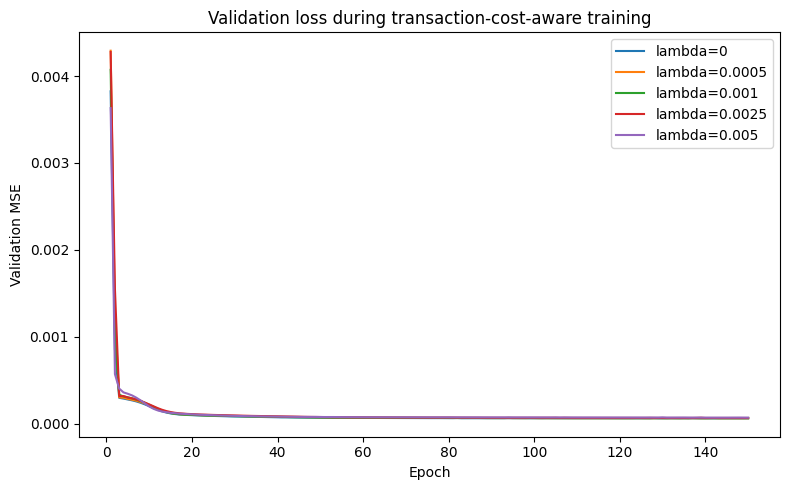

In [28]:
# Plot training curves
plt.figure(figsize=(8, 5))
for lam, hist in training_histories.items():
    plt.plot(hist["epoch"], hist["val_loss"], label=f"lambda={lam:g}")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation loss during transaction-cost-aware training")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_validation_loss.png", dpi=200)
plt.show()


## Evaluate all strategies on the common test set

For fixed benchmark strategies, the cost-adjusted premium is calibrated on the validation set, not the test set. The neural premium is the learned scalar premium.


In [29]:
# ============================================================
# Evaluation
# ============================================================

all_rows = []
notrade_selection_rows = []

bs_delta_val = bs_delta_paths(S_val)
bs_delta_test = bs_delta_paths(S_test)

# Precompute frictionless NN model, if available.
frictionless_model = trained_models.get(0.0)

for lam in COST_RATES:
    print(f"Evaluating strategies for lambda={lam:.5f}")

    all_rows.append(evaluate_delta_strategy(
        name="BS delta: frictionless premium",
        S_eval=S_test,
        delta=bs_delta_test,
        premium=BS_PRICE,
        cost_rate=lam,
    ))

    bs_cost_adjusted_premium = optimal_premium_for_fixed_delta(S_val, bs_delta_val, lam)
    all_rows.append(evaluate_delta_strategy(
        name="BS delta: cost-adjusted premium",
        S_eval=S_test,
        delta=bs_delta_test,
        premium=bs_cost_adjusted_premium,
        cost_rate=lam,
    ))

    best_band, band_df = select_no_trade_band(S_val, lam)
    band_df["Selected for cost rate"] = lam
    notrade_selection_rows.append(band_df)
    delta_band_val = apply_no_trade_band(bs_delta_val, best_band)
    delta_band_test = apply_no_trade_band(bs_delta_test, best_band)
    band_premium = optimal_premium_for_fixed_delta(S_val, delta_band_val, lam)
    all_rows.append(evaluate_delta_strategy(
        name=f"BS no-trade band: eps={best_band:g}",
        S_eval=S_test,
        delta=delta_band_test,
        premium=band_premium,
        cost_rate=lam,
    ))

    if frictionless_model is not None:
        frictionless_model.eval()
        with torch.no_grad():
            delta_frictionless_nn = frictionless_model(S_test)
            prem_frictionless_nn = float(frictionless_model.premium.detach().cpu().item())
        all_rows.append(evaluate_delta_strategy(
            name="NN trained at lambda=0",
            S_eval=S_test,
            delta=delta_frictionless_nn,
            premium=prem_frictionless_nn,
            cost_rate=lam,
        ))

    model = trained_models[lam]
    model.eval()
    with torch.no_grad():
        delta_nn = model(S_test)
        prem_nn = float(model.premium.detach().cpu().item())
    all_rows.append(evaluate_delta_strategy(
        name="Cost-aware NN",
        S_eval=S_test,
        delta=delta_nn,
        premium=prem_nn,
        cost_rate=lam,
    ))

results = pd.DataFrame(all_rows)
results.to_csv(OUTPUT_DIR / "transaction_cost_results.csv", index=False)

notrade_selection = pd.concat(notrade_selection_rows, ignore_index=True)
notrade_selection.to_csv(OUTPUT_DIR / "transaction_cost_notrade_band_selection.csv", index=False)

cols = [
    "Cost rate", "Strategy", "Premium", "RMSE", "Mean HE", "Loss CVaR95",
    "Mean cost", "Mean turnover", "HE q05", "Loss VaR95"
]
results[cols].sort_values(["Cost rate", "Strategy"]).reset_index(drop=True)


Evaluating strategies for lambda=0.00000
Evaluating strategies for lambda=0.00050
Evaluating strategies for lambda=0.00100
Evaluating strategies for lambda=0.00250
Evaluating strategies for lambda=0.00500


,Cost rate,Strategy,Premium,RMSE,Mean HE,Loss CVaR95,Mean cost,Mean turnover,HE q05,Loss VaR95
0,0.0000,BS delta: cost-adjusted premium,0.164138,0.007777,0.000038,0.017922,0.000000,4.498570,-0.012688,0.012688
1,0.0000,BS delta: frictionless premium,0.164111,0.007777,0.000011,0.017949,0.000000,4.498570,-0.012715,0.012715
2,0.0000,BS no-trade band: eps=0,0.164138,0.007777,0.000038,0.017922,0.000000,4.498570,-0.012688,0.012688
3,0.0000,Cost-aware NN,0.163976,0.007836,-0.000125,0.018391,0.000000,4.499010,-0.013097,0.013097
4,0.0000,NN trained at lambda=0,0.163976,0.007836,-0.000125,0.018391,0.000000,4.499010,-0.013097,0.013097
5,0.0005,BS delta: cost-adjusted premium,0.166389,0.007847,0.000039,0.018542,0.002249,4.498570,-0.013132,0.013132
6,0.0005,BS delta: frictionless premium,0.164111,0.008160,-0.002239,0.020820,0.002249,4.498570,-0.015410,0.015410
7,0.0005,BS no-trade band: eps=0,0.166389,0.007847,0.000039,0.018542,0.002249,4.498570,-0.013132,0.013132
8,0.0005,Cost-aware NN,0.166310,0.007896,-0.000026,0.018351,0.002233,4.465546,-0.013020,0.013020
9,0.0005,NN trained at lambda=0,0.163976,0.008271,-0.002375,0.021290,0.002250,4.499010,-0.015808,0.015808


## Main comparison plots


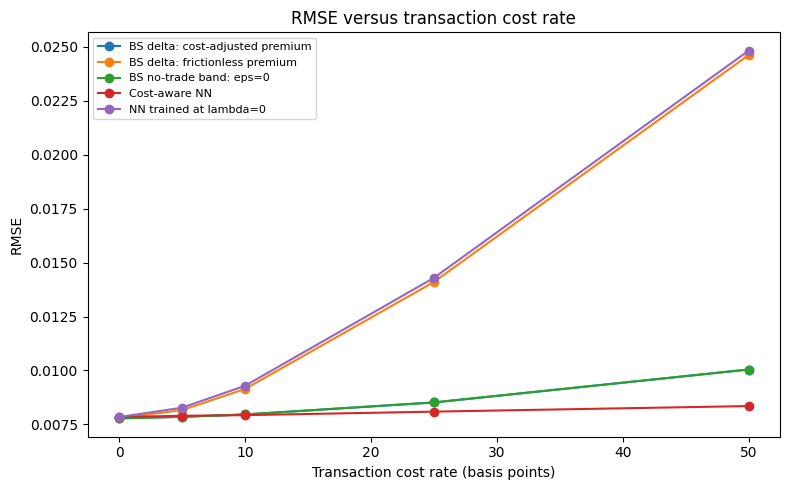

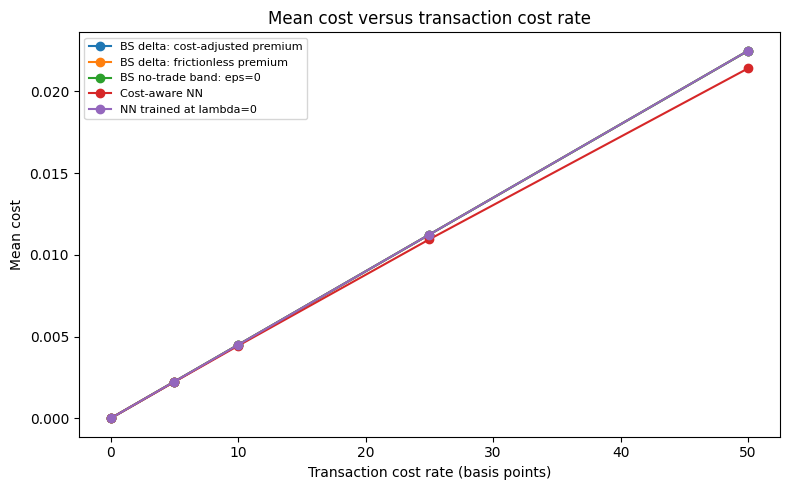

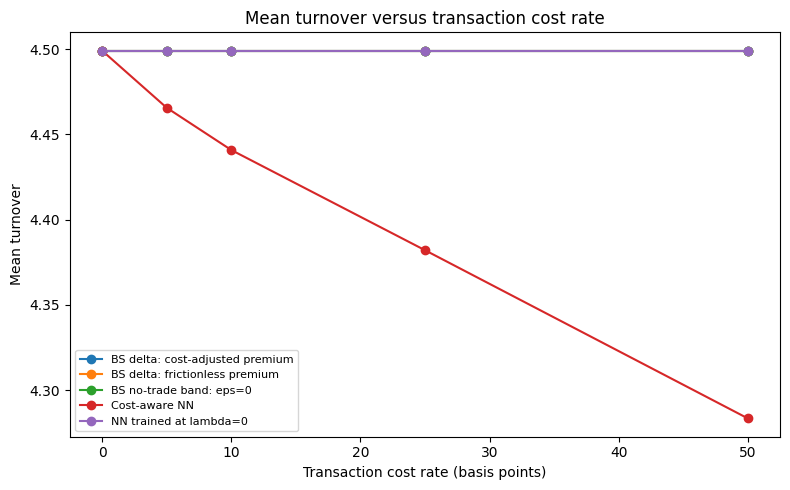

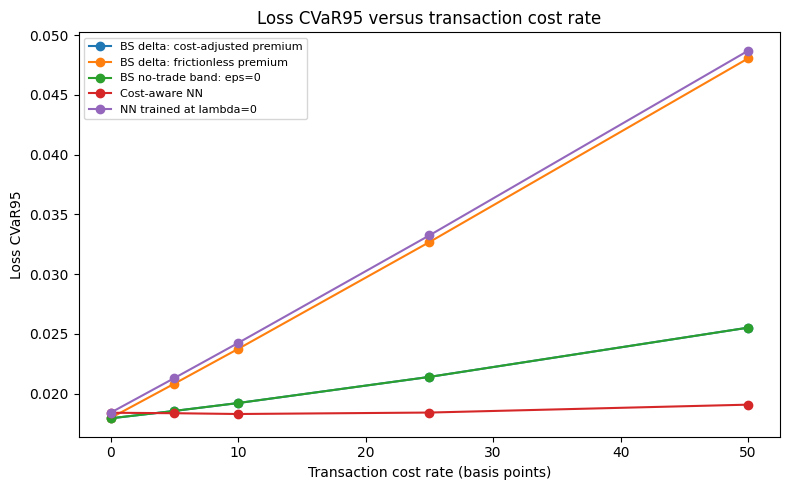

In [30]:
# ============================================================
# Plot helpers
# ============================================================

def plot_metric_by_cost_rate(results: pd.DataFrame, metric: str, filename: str):
    plt.figure(figsize=(8, 5))
    for strategy, df_s in results.groupby("Strategy"):
        df_s = df_s.sort_values("Cost rate")
        plt.plot(df_s["Cost rate"] * 10_000, df_s[metric], marker="o", label=strategy)
    plt.xlabel("Transaction cost rate (basis points)")
    plt.ylabel(metric)
    plt.title(f"{metric} versus transaction cost rate")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

plot_metric_by_cost_rate(results, "RMSE", "transaction_cost_rmse_vs_lambda.png")
plot_metric_by_cost_rate(results, "Mean cost", "transaction_cost_mean_cost_vs_lambda.png")
plot_metric_by_cost_rate(results, "Mean turnover", "transaction_cost_mean_turnover_vs_lambda.png")
plot_metric_by_cost_rate(results, "Loss CVaR95", "transaction_cost_cvar95_vs_lambda.png")


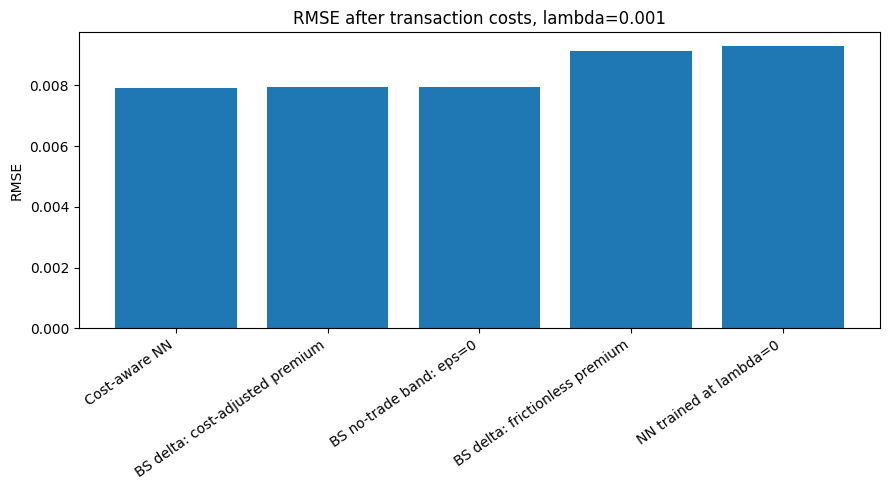

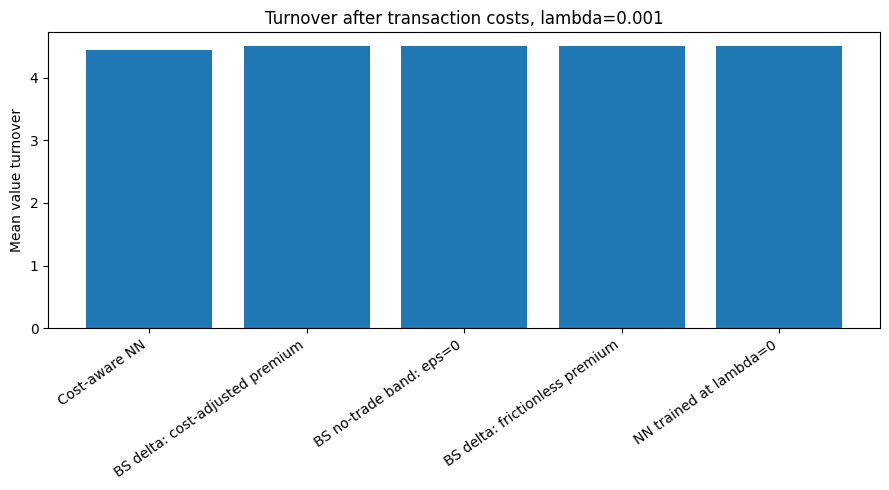

In [31]:
# Bar charts for a representative cost rate
REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
rep = results[np.isclose(results["Cost rate"], REP_LAMBDA)].copy().sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(rep["Strategy"], rep["RMSE"])
plt.ylabel("RMSE")
plt.title(f"RMSE after transaction costs, lambda={REP_LAMBDA:g}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_rmse_bar_representative.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(rep["Strategy"], rep["Mean turnover"])
plt.ylabel("Mean value turnover")
plt.title(f"Turnover after transaction costs, lambda={REP_LAMBDA:g}")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_turnover_bar_representative.png", dpi=200)
plt.show()


## Hedge-error histograms for a representative transaction cost

The histogram range is restricted for visibility, but the raw hedge errors are **not clipped** before computing the histogram.


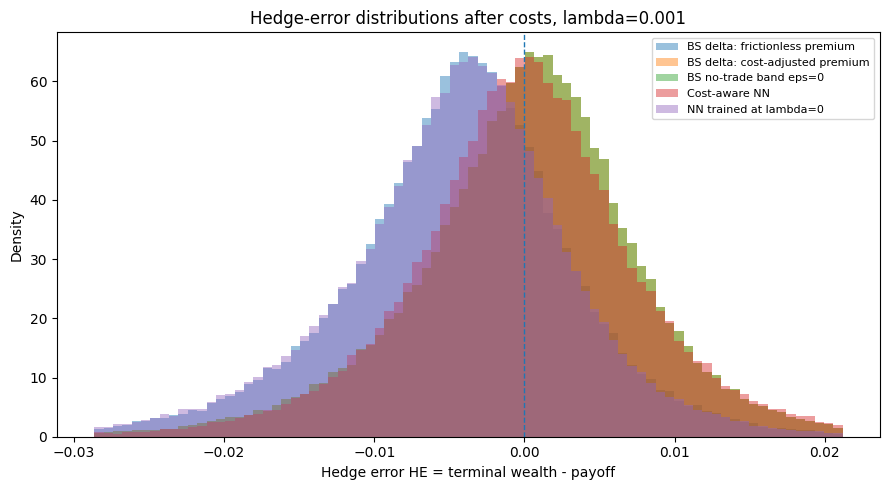

In [32]:
# ============================================================
# Representative hedge-error distributions
# ============================================================

def get_hedge_error_for_delta(S_eval, delta, premium, cost_rate):
    with torch.no_grad():
        V, _, _ = terminal_wealth_after_costs(S_eval, delta, premium, cost_rate)
        return (V - payoff_call(S_eval)).detach().cpu().numpy()

REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
he_dict = {}

he_dict["BS delta: frictionless premium"] = get_hedge_error_for_delta(
    S_test, bs_delta_test, BS_PRICE, REP_LAMBDA
)

bs_adj_prem = optimal_premium_for_fixed_delta(S_val, bs_delta_val, REP_LAMBDA)
he_dict["BS delta: cost-adjusted premium"] = get_hedge_error_for_delta(
    S_test, bs_delta_test, bs_adj_prem, REP_LAMBDA
)

best_band, _ = select_no_trade_band(S_val, REP_LAMBDA)
delta_band_val = apply_no_trade_band(bs_delta_val, best_band)
delta_band_test = apply_no_trade_band(bs_delta_test, best_band)
band_prem = optimal_premium_for_fixed_delta(S_val, delta_band_val, REP_LAMBDA)
he_dict[f"BS no-trade band eps={best_band:g}"] = get_hedge_error_for_delta(
    S_test, delta_band_test, band_prem, REP_LAMBDA
)

model = trained_models[REP_LAMBDA]
model.eval()
with torch.no_grad():
    delta_cost_nn = model(S_test)
    prem_cost_nn = float(model.premium.detach().cpu().item())
he_dict["Cost-aware NN"] = get_hedge_error_for_delta(S_test, delta_cost_nn, prem_cost_nn, REP_LAMBDA)

if frictionless_model is not None:
    frictionless_model.eval()
    with torch.no_grad():
        delta_fric_nn = frictionless_model(S_test)
        prem_fric_nn = float(frictionless_model.premium.detach().cpu().item())
    he_dict["NN trained at lambda=0"] = get_hedge_error_for_delta(
        S_test, delta_fric_nn, prem_fric_nn, REP_LAMBDA
    )

all_he = np.concatenate(list(he_dict.values()))
lo, hi = np.quantile(all_he, [0.005, 0.995])

plt.figure(figsize=(9, 5))
for name, he in he_dict.items():
    plt.hist(he, bins=80, range=(lo, hi), alpha=0.45, density=True, label=name)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Hedge error HE = terminal wealth - payoff")
plt.ylabel("Density")
plt.title(f"Hedge-error distributions after costs, lambda={REP_LAMBDA:g}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_hedge_error_histograms_representative.png", dpi=200)
plt.show()


## Average hedge ratio by moneyness

A useful diagnostic is whether the cost-aware neural hedge trades less aggressively than the Black--Scholes delta. The plot below compares average hedge ratios at the midpoint of the hedging grid.


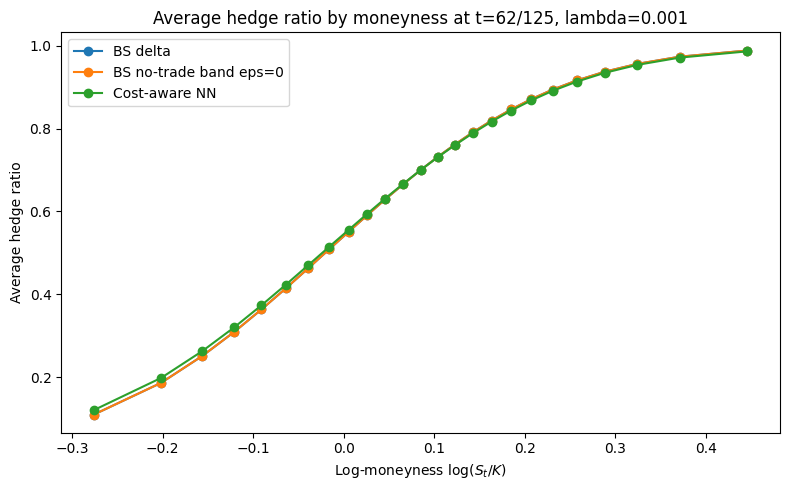

In [33]:
# ============================================================
# Average delta by moneyness at one representative time
# ============================================================

def binned_average(x, y, bins):
    idx = np.digitize(x, bins) - 1
    centers = 0.5 * (bins[:-1] + bins[1:])
    means = np.full(len(centers), np.nan)
    counts = np.zeros(len(centers), dtype=int)
    for i in range(len(centers)):
        mask = idx == i
        counts[i] = int(mask.sum())
        if counts[i] > 0:
            means[i] = y[mask].mean()
    return centers, means, counts

REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
time_index = N // 2

with torch.no_grad():
    bs_d = bs_delta_test[:, time_index].detach().cpu().numpy()
    model = trained_models[REP_LAMBDA]
    model.eval()
    nn_d = model(S_test)[:, time_index].detach().cpu().numpy()

    best_band, _ = select_no_trade_band(S_val, REP_LAMBDA)
    band_d = apply_no_trade_band(bs_delta_test, best_band)[:, time_index].detach().cpu().numpy()

moneyness = torch.log(S_test[:, time_index] / K).detach().cpu().numpy()
bins = np.quantile(moneyness, np.linspace(0.02, 0.98, 26))
bins = np.unique(bins)

centers, bs_mean, _ = binned_average(moneyness, bs_d, bins)
_, nn_mean, _ = binned_average(moneyness, nn_d, bins)
_, band_mean, _ = binned_average(moneyness, band_d, bins)

plt.figure(figsize=(8, 5))
plt.plot(centers, bs_mean, marker="o", label="BS delta")
plt.plot(centers, band_mean, marker="o", label=f"BS no-trade band eps={best_band:g}")
plt.plot(centers, nn_mean, marker="o", label="Cost-aware NN")
plt.xlabel(r"Log-moneyness $\log(S_t/K)$")
plt.ylabel("Average hedge ratio")
plt.title(f"Average hedge ratio by moneyness at t={time_index}/{N}, lambda={REP_LAMBDA:g}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_average_delta_by_moneyness.png", dpi=200)
plt.show()


## Turnover distribution

The cost-aware neural hedge should ideally reduce turnover relative to the raw Black--Scholes delta. This is the key economic mechanism behind the extension.


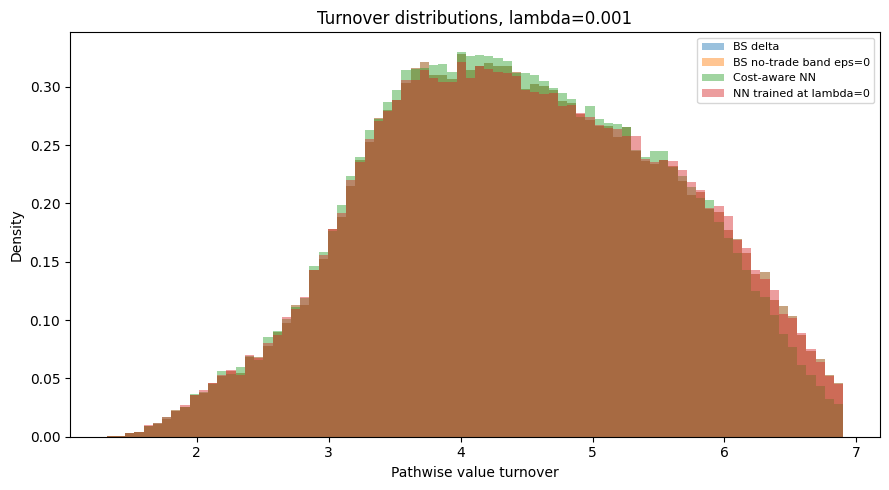

In [34]:
# ============================================================
# Turnover distribution for representative lambda
# ============================================================

def get_turnover_for_delta(S_eval, delta, cost_rate):
    with torch.no_grad():
        _, turnover = transaction_costs_and_turnover(S_eval, delta, cost_rate)
        return turnover.detach().cpu().numpy()

REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
turnover_dict = {}
turnover_dict["BS delta"] = get_turnover_for_delta(S_test, bs_delta_test, REP_LAMBDA)
turnover_dict[f"BS no-trade band eps={best_band:g}"] = get_turnover_for_delta(S_test, delta_band_test, REP_LAMBDA)
turnover_dict["Cost-aware NN"] = get_turnover_for_delta(S_test, delta_cost_nn, REP_LAMBDA)
if frictionless_model is not None:
    turnover_dict["NN trained at lambda=0"] = get_turnover_for_delta(S_test, delta_fric_nn, REP_LAMBDA)

all_turnover = np.concatenate(list(turnover_dict.values()))
lo, hi = np.quantile(all_turnover, [0.0, 0.99])

plt.figure(figsize=(9, 5))
for name, turnover in turnover_dict.items():
    plt.hist(turnover, bins=80, range=(lo, hi), alpha=0.45, density=True, label=name)
plt.xlabel("Pathwise value turnover")
plt.ylabel("Density")
plt.title(f"Turnover distributions, lambda={REP_LAMBDA:g}")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "transaction_cost_turnover_histograms_representative.png", dpi=200)
plt.show()


## Report-ready tables

The next cell produces compact CSV and LaTeX tables. For the paper, the most useful table is usually the representative cost-rate table, for example \(\lambda=10\) basis points.


In [35]:
# ============================================================
# Compact report tables
# ============================================================

display_cols = [
    "Cost rate", "Strategy", "Premium", "RMSE", "Mean HE", "Loss VaR95", "Loss CVaR95",
    "Mean cost", "Mean turnover"
]
compact = results[display_cols].copy()
compact["Cost rate (bps)"] = compact["Cost rate"] * 10_000
compact = compact[["Cost rate (bps)", "Strategy", "Premium", "RMSE", "Mean HE", "Loss VaR95", "Loss CVaR95", "Mean cost", "Mean turnover"]]
compact.to_csv(OUTPUT_DIR / "transaction_cost_compact_results.csv", index=False)

REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
rep_table = compact[np.isclose(compact["Cost rate (bps)"], REP_LAMBDA * 10_000)].copy()
rep_table = rep_table.sort_values("RMSE")
rep_table.to_csv(OUTPUT_DIR / "transaction_cost_representative_table.csv", index=False)

print("Representative cost rate:", REP_LAMBDA, "=", REP_LAMBDA * 10_000, "bps")
display(rep_table)

latex_table = rep_table.to_latex(index=False, float_format=lambda x: f"{x:.6f}")
with open(OUTPUT_DIR / "transaction_cost_representative_table.tex", "w") as f:
    f.write(latex_table)

print(latex_table)


Representative cost rate: 0.001 = 10.0 bps


,Cost rate (bps),Strategy,Premium,RMSE,Mean HE,Loss VaR95,Loss CVaR95,Mean cost,Mean turnover
14,10.0,Cost-aware NN,0.168518,0.007925,-0.000029,0.013019,0.018285,0.004441,4.440781
11,10.0,BS delta: cost-adjusted premium,0.168640,0.007958,0.000041,0.013613,0.019202,0.004499,4.498570
12,10.0,BS no-trade band: eps=0,0.168640,0.007958,0.000041,0.013613,0.019202,0.004499,4.498570
10,10.0,BS delta: frictionless premium,0.164111,0.009136,-0.004488,0.018142,0.023732,0.004499,4.498570
13,10.0,NN trained at lambda=0,0.163976,0.009284,-0.004624,0.018537,0.024229,0.004499,4.499010


\begin{tabular}{rlrrrrrrr}
\toprule
Cost rate (bps) & Strategy & Premium & RMSE & Mean HE & Loss VaR95 & Loss CVaR95 & Mean cost & Mean turnover \\
\midrule
10.000000 & Cost-aware NN & 0.168518 & 0.007925 & -0.000029 & 0.013019 & 0.018285 & 0.004441 & 4.440781 \\
10.000000 & BS delta: cost-adjusted premium & 0.168640 & 0.007958 & 0.000041 & 0.013613 & 0.019202 & 0.004499 & 4.498570 \\
10.000000 & BS no-trade band: eps=0 & 0.168640 & 0.007958 & 0.000041 & 0.013613 & 0.019202 & 0.004499 & 4.498570 \\
10.000000 & BS delta: frictionless premium & 0.164111 & 0.009136 & -0.004488 & 0.018142 & 0.023732 & 0.004499 & 4.498570 \\
10.000000 & NN trained at lambda=0 & 0.163976 & 0.009284 & -0.004624 & 0.018537 & 0.024229 & 0.004499 & 4.499010 \\
\bottomrule
\end{tabular}



## Auto-generated interpretation

Use this as a starting point only. Check that the numerical claims match your final full run before pasting into the report.


In [36]:
# ============================================================
# Report interpretation helper
# ============================================================

REP_LAMBDA = 0.0010 if 0.0010 in COST_RATES else COST_RATES[-1]
rep = results[np.isclose(results["Cost rate"], REP_LAMBDA)].copy()

try:
    bs_adj = rep[rep["Strategy"] == "BS delta: cost-adjusted premium"].iloc[0]
    nn_cost = rep[rep["Strategy"] == "Cost-aware NN"].iloc[0]

    turnover_reduction_vs_bs = 100 * (1 - nn_cost["Mean turnover"] / bs_adj["Mean turnover"])
    cost_reduction_vs_bs = 100 * (1 - nn_cost["Mean cost"] / bs_adj["Mean cost"])
    rmse_change_vs_bs = 100 * (nn_cost["RMSE"] / bs_adj["RMSE"] - 1)

    interpretation = (
        f"For a representative proportional transaction cost of {REP_LAMBDA * 10_000:.1f} basis points, "
        f"the cost-aware neural hedge achieves an RMSE of {nn_cost['RMSE']:.6f}, compared with "
        f"{bs_adj['RMSE']:.6f} for the Black--Scholes delta hedge with cost-adjusted premium. "
        f"The cost-aware neural hedge reduces mean value turnover by approximately "
        f"{turnover_reduction_vs_bs:.1f}% relative to the Black--Scholes delta benchmark, corresponding "
        f"to a mean transaction-cost reduction of approximately {cost_reduction_vs_bs:.1f}%. "
        f"The RMSE changes by approximately {rmse_change_vs_bs:.1f}% relative to the cost-adjusted "
        f"Black--Scholes delta. This illustrates the central trade-off introduced by market frictions: "
        f"the neural hedge is no longer simply trying to recover the frictionless analytic delta, but instead "
        f"learns a smoother strategy that balances replication accuracy against trading costs."
    )
    print(interpretation)
except Exception as e:
    print("Could not generate interpretation automatically:", e)


For a representative proportional transaction cost of 10.0 basis points, the cost-aware neural hedge achieves an RMSE of 0.007925, compared with 0.007958 for the Black--Scholes delta hedge with cost-adjusted premium. The cost-aware neural hedge reduces mean value turnover by approximately 1.3% relative to the Black--Scholes delta benchmark, corresponding to a mean transaction-cost reduction of approximately 1.3%. The RMSE changes by approximately -0.4% relative to the cost-adjusted Black--Scholes delta. This illustrates the central trade-off introduced by market frictions: the neural hedge is no longer simply trying to recover the frictionless analytic delta, but instead learns a smoother strategy that balances replication accuracy against trading costs.


## Files saved by this notebook

The notebook writes results to `transaction_cost_outputs/`:

- `transaction_cost_training_summary.csv`
- `transaction_cost_results.csv`
- `transaction_cost_compact_results.csv`
- `transaction_cost_representative_table.csv`
- `transaction_cost_representative_table.tex`
- `transaction_cost_notrade_band_selection.csv`
- `transaction_cost_validation_loss.png`
- `transaction_cost_rmse_vs_lambda.png`
- `transaction_cost_mean_cost_vs_lambda.png`
- `transaction_cost_mean_turnover_vs_lambda.png`
- `transaction_cost_cvar95_vs_lambda.png`
- `transaction_cost_rmse_bar_representative.png`
- `transaction_cost_turnover_bar_representative.png`
- `transaction_cost_hedge_error_histograms_representative.png`
- `transaction_cost_average_delta_by_moneyness.png`
- `transaction_cost_turnover_histograms_representative.png`


## Suggested report framing

A safe paragraph for the report is:

> Having verified that the selected neural architecture closely recovers the analytic hedge in the frictionless Black--Scholes setting, we next introduce proportional transaction costs. In this setting, frequent rebalancing is penalised, so the frictionless Black--Scholes delta is no longer the natural objective. The neural hedge is trained using the same architecture, but with transaction costs deducted directly from terminal wealth. The resulting strategy is compared with the raw Black--Scholes delta, a cost-adjusted Black--Scholes delta, and a simple no-trade-band benchmark. The purpose of the experiment is not to contradict the analytic Black--Scholes hedge in the frictionless limit, but to test whether the neural architecture can adapt when the economic objective changes.

Possible conclusion wording after checking the final numbers:

> The cost-aware neural hedge reduces turnover relative to the frictionless Black--Scholes delta and learns a smoother hedge ratio surface. This confirms that the architecture is able to adapt to market frictions rather than merely approximating the frictionless analytic delta. The improvement is therefore economic rather than purely statistical: the network trades off replication accuracy against transaction costs.
